In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual para gráficos mais elegantes no portfólio
sns.set_theme(style="whitegrid", palette="muted")

# 1. Carregando os dados
#df = pd.read_csv(r'H:\Universidade dos dados\projetos\canadian_cheese\cheese_data.csv')

df = pd.read_csv(r'C:\Users\gustavos\Documents\projetos\cheese\cheese_data.csv')


## 1. Colunas missing 

In [3]:
# Verificar valores missing por coluna
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Criar um resumo dos valores ausentes
missing_summary = pd.DataFrame({
    'Valores Faltantes': missing_values,
    'Porcentagem (%)': missing_percentage
}).sort_values(by='Valores Faltantes', ascending=False)

print(missing_summary[missing_summary['Valores Faltantes'] > 0])

                     Valores Faltantes  Porcentagem (%)
CharacteristicsEn                  399        38.291747
RindTypeEn                         321        30.806142
FlavourEn                          241        23.128599
MilkTreatmentTypeEn                 65         6.238004
CategoryTypeEn                      23         2.207294
MoisturePercent                     14         1.343570
MilkTypeEn                           1         0.095969


C:\Users\gustavos\AppData\Local\Temp\ipykernel_1168\2102193093.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=missing_percent.values, y=missing_summary.index, palette="viridis")


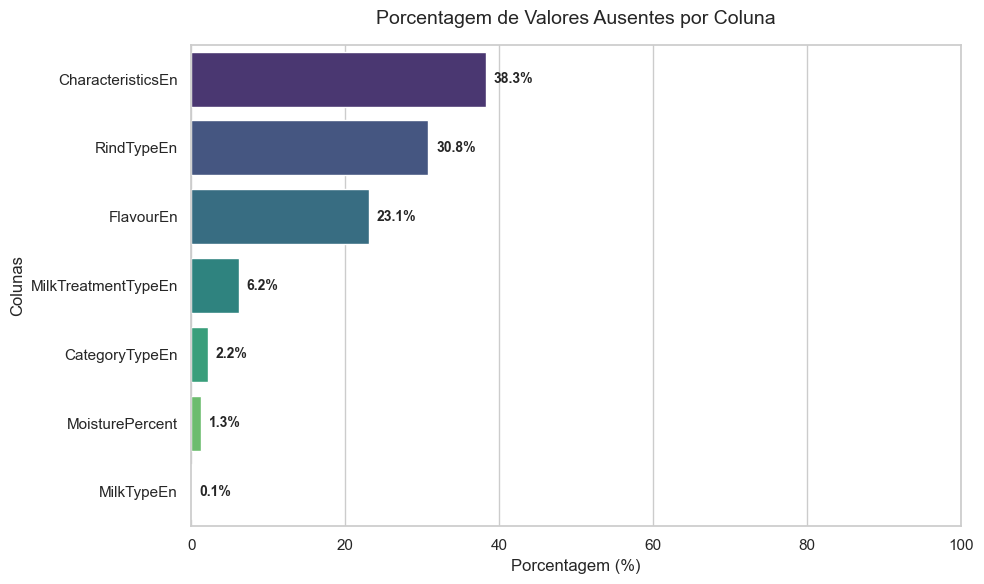

In [4]:
# Calcular valores ausentes
missing_values = df.isnull().sum()
missing_summary = missing_values[missing_values > 0].sort_values(ascending=False)
missing_percent = (missing_summary / len(df)) * 100

# Criar o gráfico
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=missing_percent.values, y=missing_summary.index, palette="viridis")

# Adicionar rótulos e título
plt.title('Porcentagem de Valores Ausentes por Coluna', fontsize=14, pad=15)
plt.xlabel('Porcentagem (%)', fontsize=12)
plt.ylabel('Colunas', fontsize=12)
plt.xlim(0, 100)

# Adicionar os valores percentuais nas barras
for i, p in enumerate(missing_percent):
    ax.annotate(f'{p:.1f}%', (p + 1, i), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('missing_values_plot.png')
plt.show()

## 2 

C:\Users\gustavos\AppData\Local\Temp\ipykernel_1168\2955949271.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[i, 0], palette='Blues_r')
C:\Users\gustavos\AppData\Local\Temp\ipykernel_1168\2955949271.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_missing, y=col, order=order, ax=axes[i, 1], palette='Oranges_r')
C:\Users\gustavos\AppData\Local\Temp\ipykernel_1168\2955949271.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[i, 0], palette='Blue

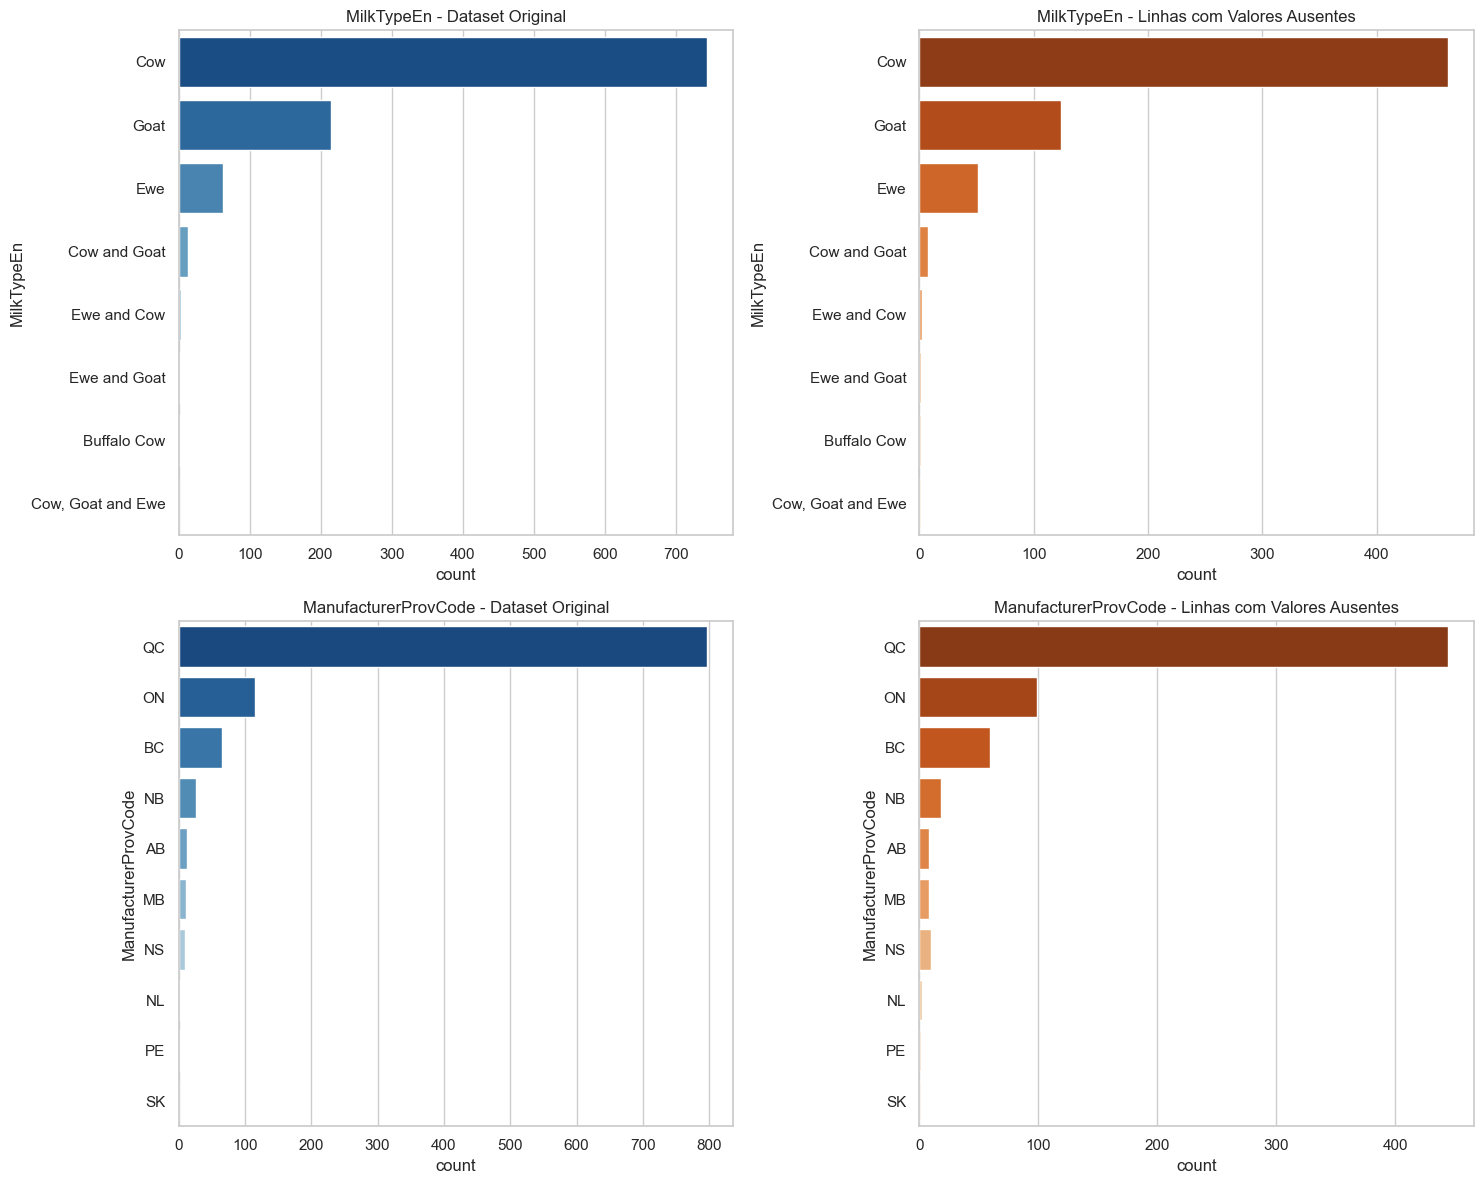

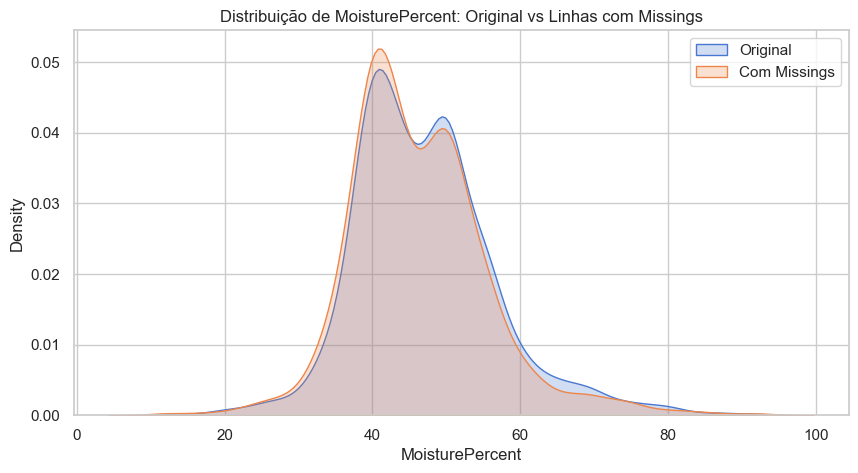

Média de MoisturePercent (Original): 47.06974708171206
Média de MoisturePercent (Com Missings): 46.1624213836478


In [5]:
# Separar linhas com qualquer valor ausente
df_missing = df[df.isnull().any(axis=1)]

# Comparar distribuições das variáveis categóricas principais
cols_to_compare = ['MilkTypeEn', 'ManufacturerProvCode']

fig, axes = plt.subplots(len(cols_to_compare), 2, figsize=(15, 12))

for i, col in enumerate(cols_to_compare):
    # Dataset Original
    order = df[col].value_counts().index[:10] # Top 10 para clareza
    sns.countplot(data=df, y=col, order=order, ax=axes[i, 0], palette='Blues_r')
    axes[i, 0].set_title(f'{col} - Dataset Original')
    
    # Dataset com Missings
    sns.countplot(data=df_missing, y=col, order=order, ax=axes[i, 1], palette='Oranges_r')
    axes[i, 1].set_title(f'{col} - Linhas com Valores Ausentes')

plt.tight_layout()
plt.savefig('comparison_distribution.png')
plt.show()

# Comparação da variável numérica 'MoisturePercent'
plt.figure(figsize=(10, 5))
sns.kdeplot(df['MoisturePercent'].dropna(), label='Original', fill=True)
sns.kdeplot(df_missing['MoisturePercent'].dropna(), label='Com Missings', fill=True)
plt.title('Distribuição de MoisturePercent: Original vs Linhas com Missings')
plt.legend()
plt.savefig('moisture_comparison.png')
plt.show()

# Estatísticas descritivas para comparação
print("Média de MoisturePercent (Original):", df['MoisturePercent'].mean())
print("Média de MoisturePercent (Com Missings):", df_missing['MoisturePercent'].mean())

## 3. % de gordura - queijo orgnanico x nao organico

Distribuição de Nível de Gordura (%) por Categoria:
FatLevel  higher fat  lower fat
Organic                        
0          33.085896  66.914104
1          46.464646  53.535354


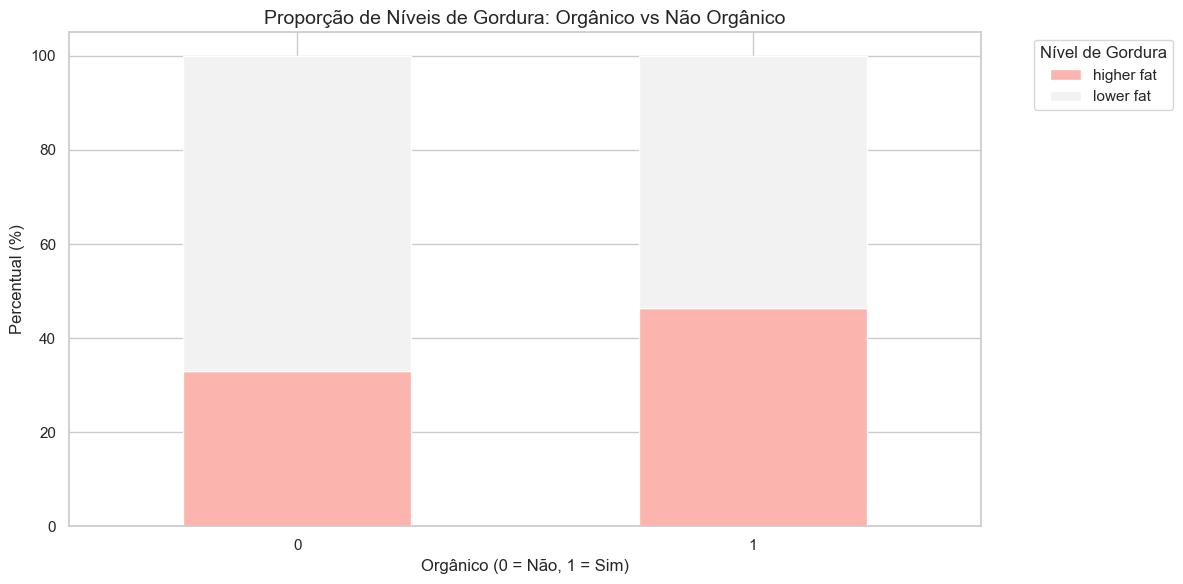

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# No dataset 'cheese_data.csv', a coluna de gordura é qualitativa ('FatLevel') e a orgânica é 'Organic'
# Vamos analisar a distribuição de FatLevel para queijos orgânicos e não orgânicos

# Mapear a ordem lógica do FatLevel se necessário
fat_order = df['FatLevel'].unique()

# Tabela de contingência para ver a relação
contingency = pd.crosstab(df['Organic'], df['FatLevel'], normalize='index') * 100

print("Distribuição de Nível de Gordura (%) por Categoria:")
print(contingency)

# Visualização
plt.figure(figsize=(12, 6))
contingency.plot(kind='bar', stacked=True, colormap='Pastel1', ax=plt.gca())
plt.title('Proporção de Níveis de Gordura: Orgânico vs Não Orgânico', fontsize=14)
plt.xlabel('Orgânico (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.legend(title='Nível de Gordura', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fat_organic_dist.png')
plt.show()

C:\Users\gustavos\AppData\Local\Temp\ipykernel_1168\2885575062.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='FatLevel', y='MoisturePercent', palette='coolwarm')


Correlação de Pearson entre Umidade e Nível de Gordura: -0.4954

Estatísticas de Umidade por Nível de Gordura:
            count       mean       std   min   25%   50%    75%   max
FatLevel                                                             
higher fat  356.0  40.543539  6.714935  12.0  38.0  39.0  44.25  68.0
lower fat   672.0  50.527083  9.078335  20.0  44.0  50.0  55.00  92.0


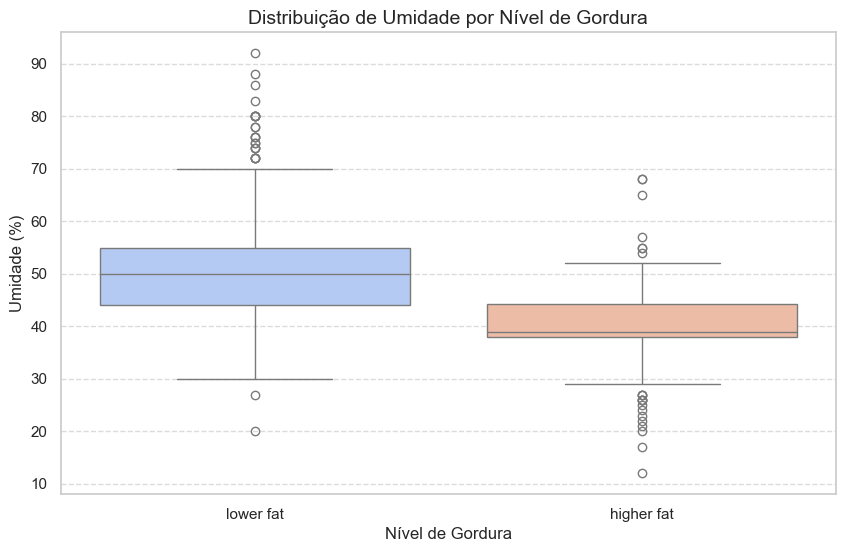

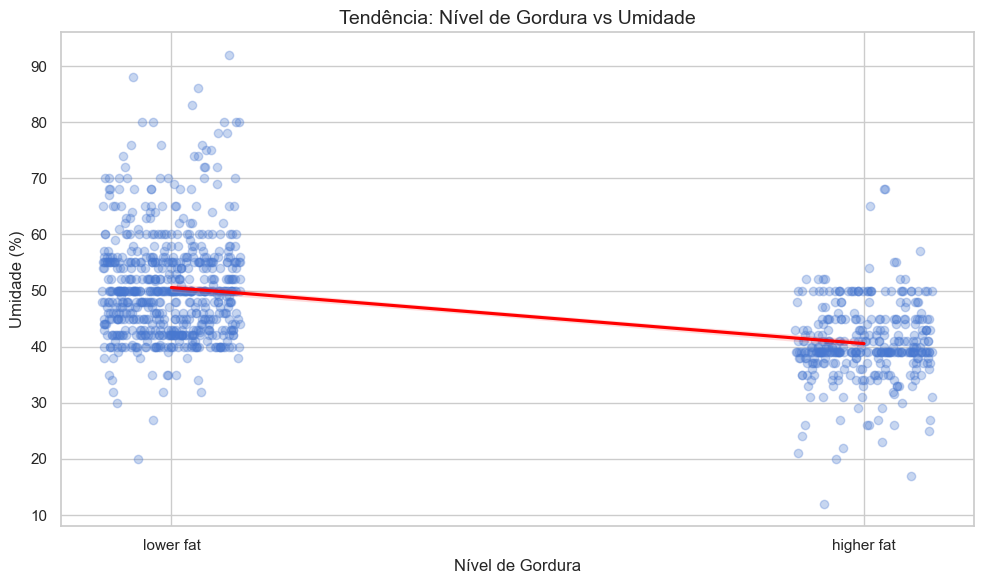

In [7]:
# Criar uma versão numérica simplificada do FatLevel para correlação
# 'lower fat' = 0, 'higher fat' = 1
fat_map = {'lower fat': 0, 'higher fat': 1}
df['FatLevelNum'] = df['FatLevel'].map(fat_map)

# Calcular correlação
correlation = df['MoisturePercent'].corr(df['FatLevelNum'])

# Visualização: Boxplot de Umidade por Nível de Gordura
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='FatLevel', y='MoisturePercent', palette='coolwarm')
plt.title('Distribuição de Umidade por Nível de Gordura', fontsize=14)
plt.xlabel('Nível de Gordura', fontsize=12)
plt.ylabel('Umidade (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Scatter plot com regressão para visualizar a tendência (usando jitter para categorias)
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='FatLevelNum', y='MoisturePercent', x_jitter=0.1, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Tendência: Nível de Gordura vs Umidade', fontsize=14)
plt.xticks([0, 1], ['lower fat', 'higher fat'])
plt.xlabel('Nível de Gordura', fontsize=12)
plt.ylabel('Umidade (%)', fontsize=12)

plt.tight_layout()
plt.savefig('moisture_fat_relation.png')

print(f"Correlação de Pearson entre Umidade e Nível de Gordura: {correlation:.4f}")
print("\nEstatísticas de Umidade por Nível de Gordura:")
print(df.groupby('FatLevel')['MoisturePercent'].describe())

#A correlação de Pearson de -0,4954 indica uma correlação negativa moderada. Isso significa que, à medida que o nível de gordura aumenta, o percentual de umidade tende a diminuir.

## 5. Análise por província 

In [8]:
# Criar uma tabela de distribuição cruzada (Crosstab) 
# Escolhendo ManufacturerProvCode e CategoryTypeEn como colunas representativas para a análise
cross_tab = pd.crosstab(df['ManufacturerProvCode'], df['CategoryTypeEn'], margins=True, margins_name="Total")

# Exibir a tabela
print(cross_tab)

CategoryTypeEn        Firm Cheese  Fresh Cheese  Hard Cheese  \
ManufacturerProvCode                                           
AB                              5             3            0   
BC                             28             2            8   
MB                              7             0            0   
NB                              3             6            0   
NL                              1             0            0   
NS                              2             0            1   
ON                             27            23           13   
PE                              2             0            0   
QC                            274            85           10   
SK                              0             0            0   
Total                         349           119           32   

CategoryTypeEn        Semi-soft Cheese  Soft Cheese  Veined Cheeses  Total  
ManufacturerProvCode                                                        
AB           

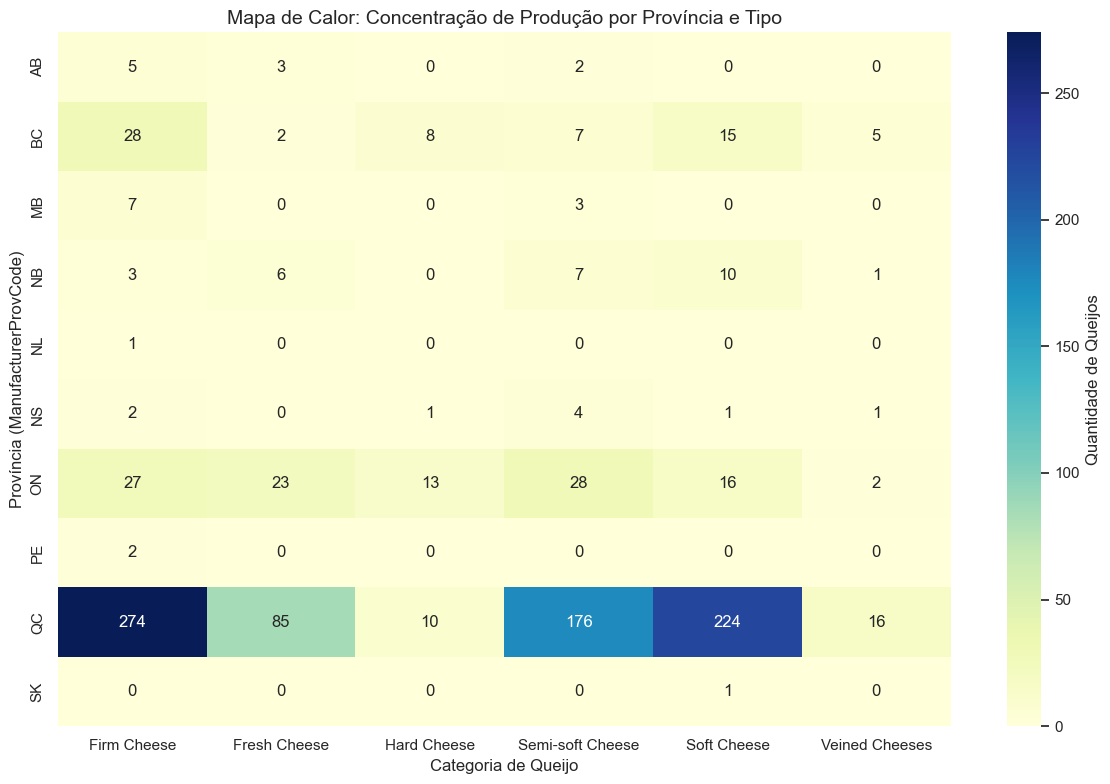

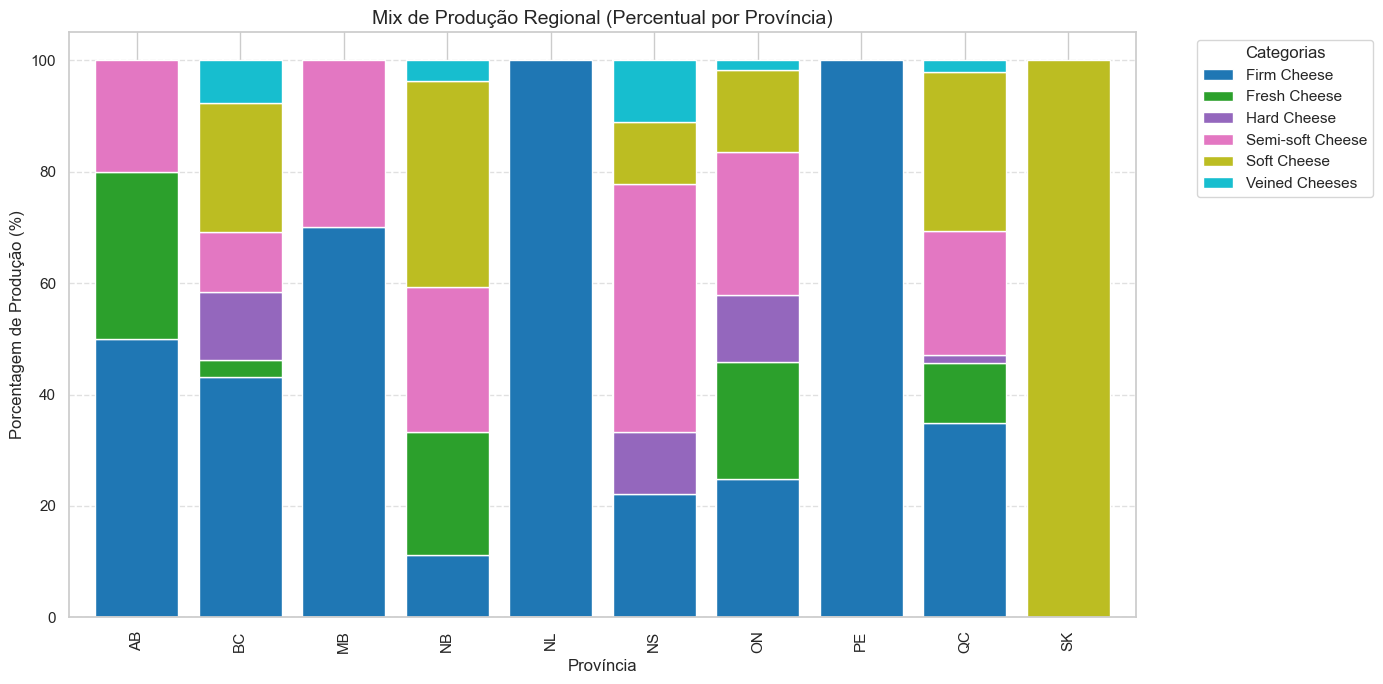

In [9]:
# Criar a tabela de contingência para o heatmap
ct = pd.crosstab(df['ManufacturerProvCode'], df['CategoryTypeEn'])

# 1. Heatmap de Frequência
plt.figure(figsize=(12, 8))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Quantidade de Queijos'})
plt.title('Mapa de Calor: Concentração de Produção por Província e Tipo', fontsize=14)
plt.xlabel('Categoria de Queijo', fontsize=12)
plt.ylabel('Província (ManufacturerProvCode)', fontsize=12)
plt.tight_layout()
plt.savefig('heatmap_cheese.png')
plt.show()

# 2. Gráfico de Barras Empilhadas (Normalizado para 100% para ver o "mix" de cada província)
ct_perc = pd.crosstab(df['ManufacturerProvCode'], df['CategoryTypeEn'], normalize='index') * 100

ax = ct_perc.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab10', width=0.8)
plt.title('Mix de Produção Regional (Percentual por Província)', fontsize=14)
plt.xlabel('Província', fontsize=12)
plt.ylabel('Porcentagem de Produção (%)', fontsize=12)
plt.legend(title='Categorias', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adicionar labels de texto para as maiores fatias (opcional para clareza)
plt.tight_layout()
plt.savefig('stacked_bar_cheese.png')
plt.show()

## 6. REPRESENTATIVIDADE DOS QUEIJOS (CABRA X VACA )

C:\Users\gustavos\AppData\Local\Temp\ipykernel_1168\1104215322.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=milk_counts.index, y=milk_counts.values, ax=ax[0], palette='pastel')


Frequência de Tipos de Leite:
MilkTypeEn
Cow     743
Goat    214
Name: count, dtype: int64

Distribuição de Gordura (%):
FatLevel    higher fat  lower fat
MilkTypeEn                       
Cow          39.973082  60.026918
Goat         13.551402  86.448598


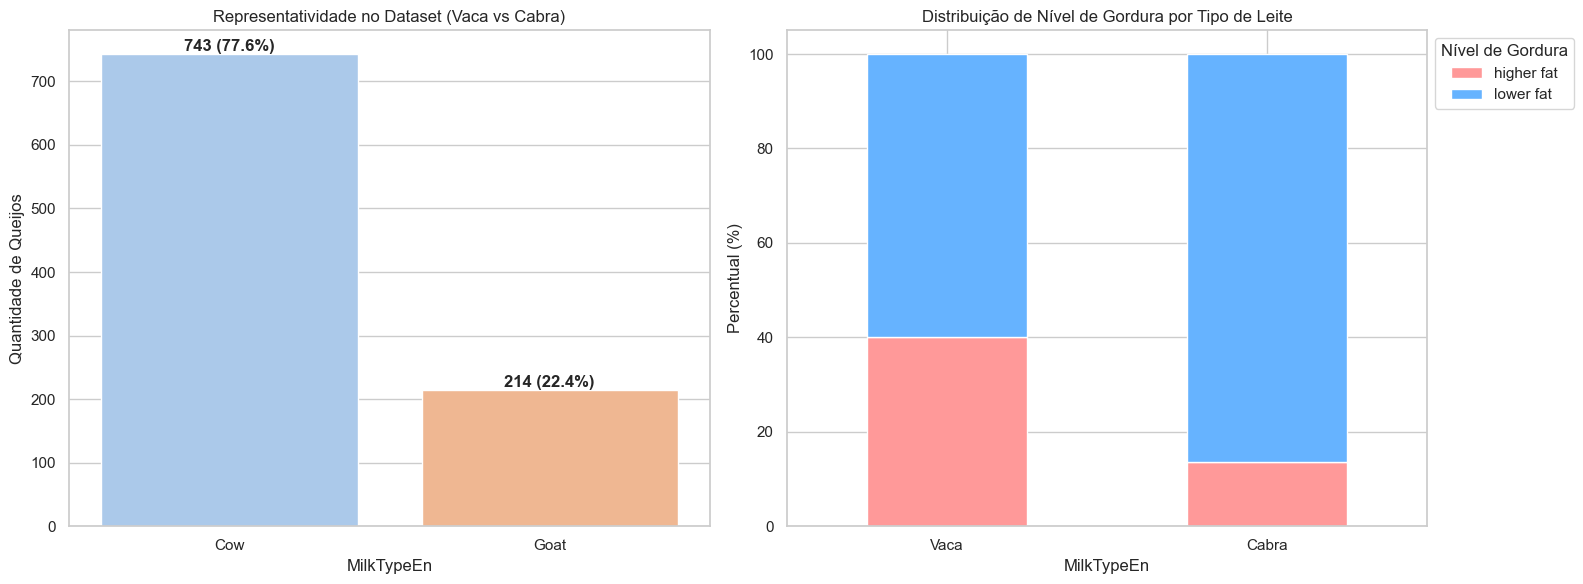

In [10]:
# Filtrar apenas vaca e cabra para comparação direta
df_filtered = df[df['MilkTypeEn'].isin(['Cow', 'Goat'])]

# 1. Representatividade (Contagem)
milk_counts = df_filtered['MilkTypeEn'].value_counts()
milk_perc = df_filtered['MilkTypeEn'].value_counts(normalize=True) * 100

# 2. Comparação de Gordura (FatLevel)
# Criar uma tabela de contingência para gordura
fat_milk_dist = pd.crosstab(df_filtered['MilkTypeEn'], df_filtered['FatLevel'], normalize='index') * 100

# Visualização
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Representatividade
sns.barplot(x=milk_counts.index, y=milk_counts.values, ax=ax[0], palette='pastel')
ax[0].set_title('Representatividade no Dataset (Vaca vs Cabra)')
ax[0].set_ylabel('Quantidade de Queijos')
for i, v in enumerate(milk_counts.values):
    ax[0].text(i, v + 5, f"{v} ({milk_perc.iloc[i]:.1f}%)", ha='center', fontweight='bold')

# Gráfico de Gordura
fat_milk_dist.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff9999','#66b3ff'])
ax[1].set_title('Distribuição de Nível de Gordura por Tipo de Leite')
ax[1].set_ylabel('Percentual (%)')
ax[1].set_xticklabels(['Vaca', 'Cabra'], rotation=0)
ax[1].legend(title='Nível de Gordura', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('cow_vs_goat.png')

print("Frequência de Tipos de Leite:")
print(milk_counts)
print("\nDistribuição de Gordura (%):")
print(fat_milk_dist)

## 7 Distribuição dos tipos de queijos 

C:\Users\gustavos\AppData\Local\Temp\ipykernel_1168\4125715279.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=m_counts.index, y=m_counts.values, ax=ax[0], palette='viridis')
C:\Users\gustavos\AppData\Local\Temp\ipykernel_1168\4125715279.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ManufacturingTypeEn', y='MoisturePercent', data=df, ax=ax[1], palette='magma')


Frequência de Fabricação:
ManufacturingTypeEn
Industrial    455
Artisan       367
Farmstead     220
Name: count, dtype: int64

Percentual Orgânico por Tipo:
Organic                      0          1
ManufacturingTypeEn                      
Artisan              91.553134   8.446866
Farmstead            74.545455  25.454545
Industrial           97.362637   2.637363

Média de Umidade por Tipo:
ManufacturingTypeEn
Artisan       46.431129
Farmstead     47.169863
Industrial    47.540359
Name: MoisturePercent, dtype: float64


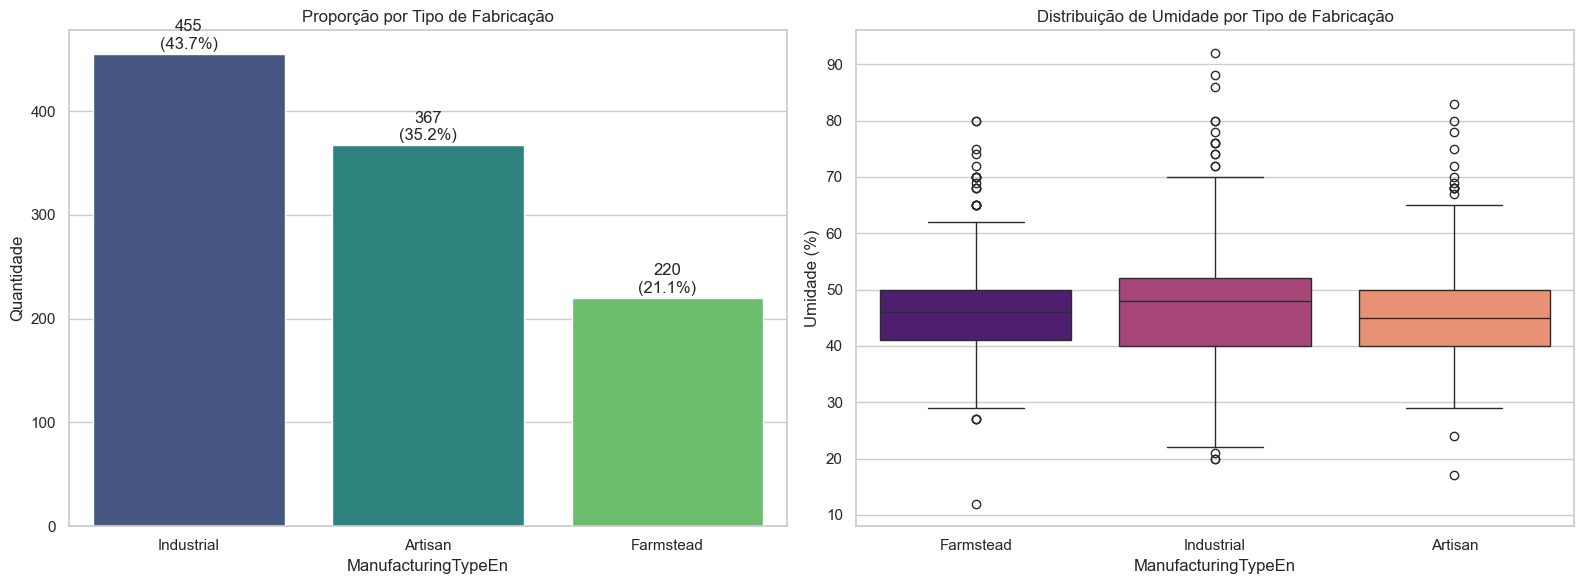

In [11]:
# 1. Proporção de tipos de fabricação (ManufacturingTypeEn)
m_counts = df['ManufacturingTypeEn'].value_counts()
m_perc = df['ManufacturingTypeEn'].value_counts(normalize=True) * 100

# 2. Relação entre Tipo de Fabricação e Ser Orgânico
organic_m = pd.crosstab(df['ManufacturingTypeEn'], df['Organic'], normalize='index') * 100

# 3. Relação entre Tipo de Fabricação e Umidade (MoisturePercent)
moisture_m = df.groupby('ManufacturingTypeEn')['MoisturePercent'].mean()

# Visualização
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Proporção de Fabricação
sns.barplot(x=m_counts.index, y=m_counts.values, ax=ax[0], palette='viridis')
ax[0].set_title('Proporção por Tipo de Fabricação')
ax[0].set_ylabel('Quantidade')
for i, v in enumerate(m_counts.values):
    ax[0].text(i, v + 5, f"{v}\n({m_perc.iloc[i]:.1f}%)", ha='center')

# Gráfico de Umidade por Tipo de Fabricação
sns.boxplot(x='ManufacturingTypeEn', y='MoisturePercent', data=df, ax=ax[1], palette='magma')
ax[1].set_title('Distribuição de Umidade por Tipo de Fabricação')
ax[1].set_ylabel('Umidade (%)')

plt.tight_layout()
plt.savefig('manufacturing_analysis.png')

print("Frequência de Fabricação:")
print(m_counts)
print("\nPercentual Orgânico por Tipo:")
print(organic_m)
print("\nMédia de Umidade por Tipo:")
print(moisture_m)

## 8 Sabores de queijos 

FatLevel                                    higher fat  lower fat  Total
FlavourEn                                                               
Mild                                                11         48     59
Sharp                                                2         11     13
Hazelnut flavor that intensifies with age            9          1     10
Hazelnut flavour that intensifies with age           9          0      9
Milk, hazelnut and mushroom flavor                   0          6      6
Salty                                                0          6      6
Pronounced                                           3          2      5
Mild and salty                                       0          5      5
Hazelnut flavor                                      3          1      4
Rich and creamy taste                                0          4      4
Nutty flavour                                        1          3      4
Lactic                                             

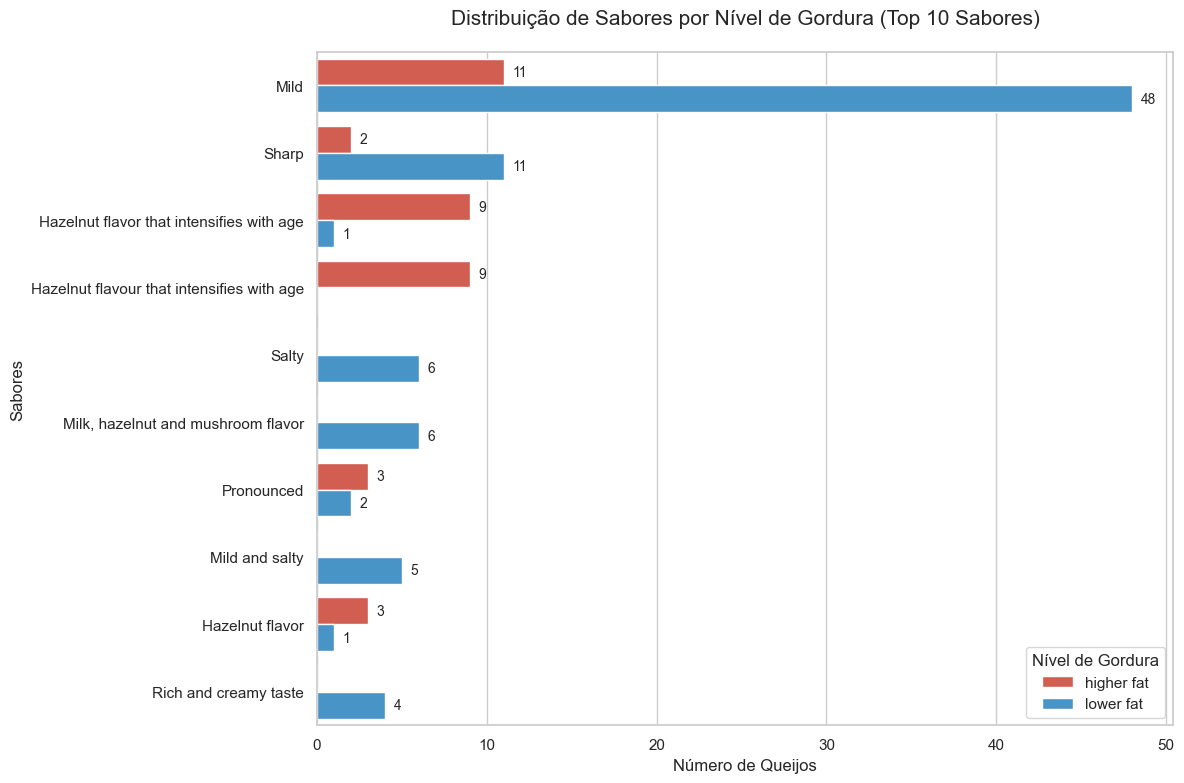

In [13]:
# Criar a contagem de sabores (FlavourEn) cruzada com o nível de gordura (FatLevel)
# Removendo valores nulos de FlavourEn para uma análise mais limpa
flavour_fat_counts = df.dropna(subset=['FlavourEn']).groupby(['FlavourEn', 'FatLevel']).size().unstack(fill_value=0)

# Calcular o total por sabor para ordenar pelos mais comuns
flavour_fat_counts['Total'] = flavour_fat_counts.sum(axis=1)
flavour_fat_counts = flavour_fat_counts.sort_values(by='Total', ascending=False)

# Exibir os 15 sabores mais frequentes
print(flavour_fat_counts.head(15))

# Limpar dados: remover sabores nulos e selecionar os mais comuns
# Vamos focar nos 10 sabores mais frequentes para evitar poluição visual
top_flavours = df['FlavourEn'].value_counts().nlargest(10).index
df_plot = df[df['FlavourEn'].isin(top_flavours)]

# Criar a tabela de contagem
plot_data = pd.crosstab(df_plot['FlavourEn'], df_plot['FatLevel']).reset_index()

# Derreter o dataframe para facilitar o plot com Seaborn
plot_data_melted = plot_data.melt(id_vars='FlavourEn', var_name='Nível de Gordura', value_name='Quantidade')

# Ordenar por quantidade total para o gráfico ficar mais organizado
order = df_plot['FlavourEn'].value_counts().index

# Criar a visualização
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Gráfico de barras horizontais
ax = sns.barplot(
    data=plot_data_melted, 
    y='FlavourEn', 
    x='Quantidade', 
    hue='Nível de Gordura', 
    palette={'higher fat': '#e74c3c', 'lower fat': '#3498db'},
    order=order
)

# Customização estética
plt.title('Distribuição de Sabores por Nível de Gordura (Top 10 Sabores)', fontsize=15, pad=20)
plt.xlabel('Número de Queijos', fontsize=12)
plt.ylabel('Sabores', fontsize=12)
plt.legend(title='Nível de Gordura', frameon=True)

# Adicionar os números nas barras
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{int(width)}', 
                    (width + 0.5, p.get_y() + p.get_height() / 2), 
                    va='center', fontsize=10)

plt.tight_layout()
plt.savefig('flavour_fat_distribution.png')
plt.show()

## 9 

C:\Users\gustavos\AppData\Local\Temp\ipykernel_1168\3794389447.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RindTypeEn', y='MoisturePercent', data=df, palette='Set3')


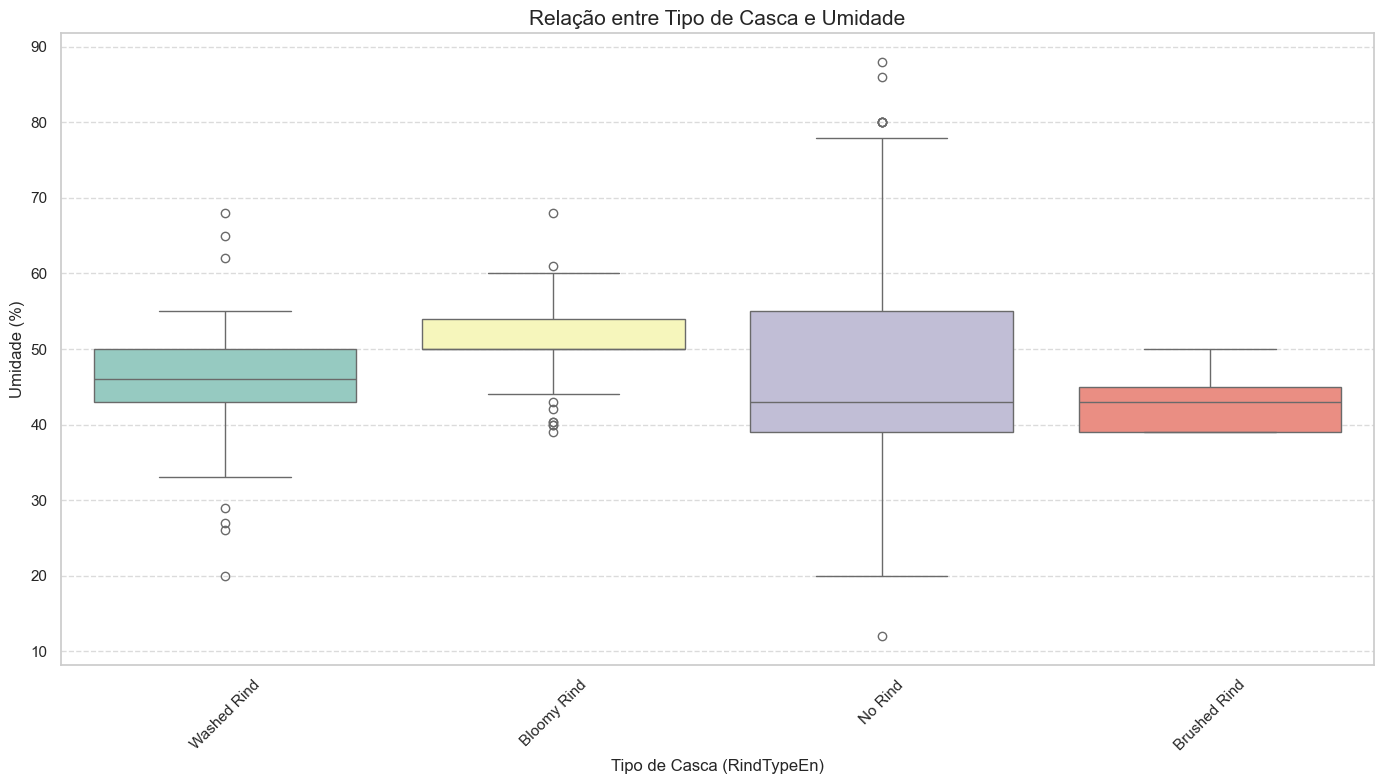

Distribuição de Tipos de Queijo por Tipo de Casca:
CategoryTypeEn  Firm Cheese  Fresh Cheese  Hard Cheese  Semi-soft Cheese  \
RindTypeEn                                                                 
Bloomy Rind               3             4            0                 6   
Brushed Rind              2             0            0                 3   
No Rind                 201            86           12                59   
Washed Rind              27             0            1                86   

CategoryTypeEn  Soft Cheese  Veined Cheeses  
RindTypeEn                                   
Bloomy Rind             148               2  
Brushed Rind              0               0  
No Rind                  40               1  
Washed Rind              32               0  


In [14]:
# 1. Relação entre tipo de casca (RindTypeEn) e tipo de queijo (CategoryTypeEn)
rind_category_cross = pd.crosstab(df['RindTypeEn'], df['CategoryTypeEn'])

# 2. Relação entre tipo de casca e umidade (MoisturePercent)
# Criar Boxplot conforme solicitado
plt.figure(figsize=(14, 8))
sns.boxplot(x='RindTypeEn', y='MoisturePercent', data=df, palette='Set3')
plt.title('Relação entre Tipo de Casca e Umidade', fontsize=15)
plt.xlabel('Tipo de Casca (RindTypeEn)', fontsize=12)
plt.ylabel('Umidade (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('rind_moisture_boxplot.png')
plt.show()

# Mostrar a tabela cruzada para responder a primeira parte da pergunta
print("Distribuição de Tipos de Queijo por Tipo de Casca:")
print(rind_category_cross)

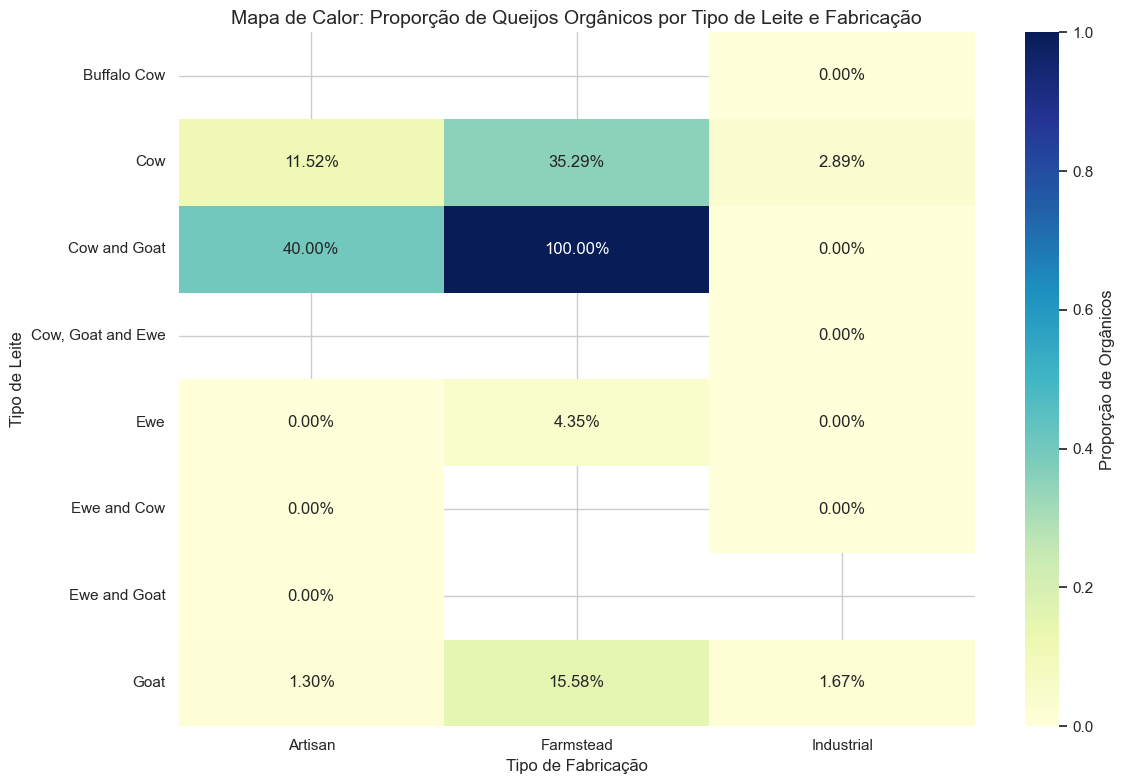

Matriz de proporção de queijos orgânicos:
ManufacturingTypeEn   Artisan  Farmstead  Industrial
MilkTypeEn                                          
Buffalo Cow               NaN        NaN    0.000000
Cow                  0.115226   0.352941    0.028871
Cow and Goat         0.400000   1.000000    0.000000
Cow, Goat and Ewe         NaN        NaN    0.000000
Ewe                  0.000000   0.043478    0.000000
Ewe and Cow          0.000000        NaN    0.000000
Ewe and Goat         0.000000        NaN         NaN
Goat                 0.012987   0.155844    0.016667


In [15]:
# Selecionar variáveis categóricas relevantes para a análise multivariada
# Vamos usar o Tipo de Leite (MilkTypeEn) e o Tipo de Fabricação (ManufacturingTypeEn)
# como eixos, e a proporção de queijos orgânicos (Organic) como valor.

# Criar a tabela dinâmica calculando a média da coluna 'Organic' 
# (isso resulta na proporção, já que Organic é 0 ou 1)
heatmap_data = df.pivot_table(index='MilkTypeEn', 
                             columns='ManufacturingTypeEn', 
                             values='Organic', 
                             aggfunc='mean')

# Visualização
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='.2%', cbar_kws={'label': 'Proporção de Orgânicos'})

plt.title('Mapa de Calor: Proporção de Queijos Orgânicos por Tipo de Leite e Fabricação', fontsize=14)
plt.ylabel('Tipo de Leite', fontsize=12)
plt.xlabel('Tipo de Fabricação', fontsize=12)

plt.tight_layout()
plt.savefig('organic_heatmap.png')
plt.show()

print("Matriz de proporção de queijos orgânicos:")
print(heatmap_data)